# NLP Lab 2 / Text classification

You may work by pairs. There is no increase of grade or compensation if you work alone. 
Please first indicate whom you work with in the cell above:

In [2]:
#Your answer here : I worked with Axel Blois

# 0. Submission instructions

The due date of this lab is December 9, 23:59. Late deliveries will be penalized 1pt/day. 

Please visit https://mvproxy.esiee.fr (disregard the security warning, the certificate is self-signed). When visiting for the first time, provide your ESIEE login, but leave the password field empty, and click on "Connexion". You should then receive an email containing your mvproxy password (check your SPAM folder if you don't).

Visit https://mvproxy.esiee.fr a second time, but now fill in both your ESIEE login and mvproxy password. You should be logged in.

Drop a ZIP archive containing :
- This notebook (lab2.ipynb), filled with answers to the questions ;
- and a *local* copy of the text articles or CSV files you are working with, which you should access to relatively and not absolutely. 

Please pay attention to the latter point. Code like
```
csv.reader('C:\Users\Yoyodyne\My Documents\AIC-5102B\Lab2 Text Classification/dataset.csv')
```

should be banned, and replaced by
```
csv.reader('dataset.csv')
```
or
```
csv.read('./data/class1.csv')
csv.read('./data/class2.csv')
```

I should be able to run your code on *Linux* after sourcing <t>~/pynlp/bin/activate</t> , without modifying the 'C:\Users\Yoyodyne\My Documents\AIC-5102B' path, which I don't have access to, nor changing anything else in your notebook as I run it. You must also stick to NLTK, and packages I include myself in the following code snippets.


## 1. Setup

This lab must be done on Linux Debian 12, under the Python virtual environment [decribed here](https://perso.esiee.fr/~hilairex/NLP/docker-fc39.html). You may also use the Docker container described in this document if you prefer, but the Python venv is enough.

It is all about text classification, and your first task will consist in selecting a dataset.

Please visit https://www.kaggle.com/datasets?search=text+classification in order to choose a dataset you like (or randomly, if you don't known which one to choose). We will attempt to separate samples from 2 classes only, so you may either choose between a dataset that has natively 2 classes only (spam/non spam email, positive/negative review, etc.) or one that has natively $n > 2$ classes, but two only of which will be used (e.g. politics/cooking, or sport/computer articles).

Which dataset and classes did you chose ? Plesase give your answer below with its related URL, and copy the related files to your working directory.


In [3]:
# Your answer here
# On a choisi le dataset "SMS Spam Collection Dataset" de Kaggle :
# https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
# Il contient deux classes : "ham" (message normal) et "spam".


## 2. Text vectorization

The following functions :
- extract the vocabulary from a CSV file assuming the text is located in column number 5
- build the document-term matrix by reading again the same CSV file

Adapt them, so that they fit your dataset and produce a document-term matrix in the end.

Please note that:
- the tokenization method used is wordpunct_tokenize(), which may not be optimal. You may call something different in case you find too much garbage in your resulting vocabulary.
- there are two "if" tests in dtmat_from_file which appear unnecessary so far. They are, indeed, because the test samples may include unseen words, which would generate out-of-bounds index. So unseen words are just ignored.
- you may also consider lemmatizing. 

In [4]:
import csv
import nltk
import numpy as np
import sys

# Charger le dataset
rows = []
with open("data/spam.csv", "r", encoding="latin-1") as f:
    reader = csv.reader(f)
    for r in reader:
        rows.append(r)

# rows[:1]
# print(len(rows))

def voc_from_csv(csvfile):
    nlines=0
    voc=[]
    with open(csvfile, errors='ignore') as file:
        reader=csv.reader(file, delimiter=',')
        for row in reader:
            nlines=nlines+1
            voc.extend(nltk.wordpunct_tokenize(row[1]))
    voc=sorted(set(voc))        
    return voc,nlines

def dtmat_from_csv(csvfile):
    voc,rows=voc_from_csv(csvfile)
    cols=len(voc)
    mat=np.zeros((rows,cols))
    d=0
    with open(csvfile,  errors='ignore') as file:
        reader=csv.reader(file, delimiter=',')
        for row in reader:
            w= nltk.wordpunct_tokenize(row[1])
            X=np.searchsorted(voc,w,side='left')            
            for i in range(0,len(w)):
                if (X[i] < cols):
                    if (w[i] == voc[X[i]]):
                        mat[d][X[i]]+=1
            d=d+1
    return mat


### Question 1 

Run dtmat_from_csv on your dataset, or on a sample drawn from it if it is very large. Examine the resulting matrix. How many times does it happen that a given word is seen only once (possibly twice) in your training set ? Give a few Python code lines which show this below.

### your answer here

In [5]:
mat = dtmat_from_csv("data/spam.csv")

# somme des mots (colonne)
counts = mat.sum(axis=0)

# mots vus 1 fois
one = np.sum(counts == 1)

# mots vus 1 ou 2 fois
one_two = np.sum((counts == 1) | (counts == 2))

one, one_two

(np.int64(5698), np.int64(7519))

In [6]:
# Vérification que la matrice est creuse 
zero_ratio = 1 - (np.count_nonzero(mat) / mat.size)
zero_ratio


np.float64(0.9984604458924276)

On applique la fonction pour obtenir la matrice document-terme, puis on regarde la somme de chaque colonne pour savoir combien de fois chaque mot apparaît dans tout le dataset. Ensuite, on compte simplement le nombre de mots qui apparaissent une seule fois, ou une à deux fois comme demandé dans l’énoncé. On observe qu’il y a beaucoup de mots rares, ce qui est normal avec des SMS où le vocabulaire est très varié.

### Question 2

In this part, we are a interested in separating the two classes you chose by linear discriminant analysis (LDA). You have the choice between 3 strategies:

1. Use the direct formula $u=W^{-1}(m_1-m_2)$, as stated in [the course](https://perso.esiee.fr/~hilairex/AIC-5102B/complements.pdf)
2. Use the kernelized version of LDA, also explained in [the course](https://perso.esiee.fr/~hilairex/AIC-5102B/complements.pdf), the kernel of which will simply be $k(x,y) = <x,y>$ to comply with the statement
3. Use an alternative (possibly smarter) strategy

Remember that all that is requested here is to classify using LDA. As a clue, several methods are available to compute the $k$ highest eigenvalues/eigenvectors or singular values/singular vectors of an $m\times n$ matrix :
- if the matrix is sparse : Lanczos-like methods are quite efficient, with respective time and memory complexities of $O(nnz.k)$ and $O(nnz + (n+m)k)$. Python's <t>scipy.sparse.linalg.svds</t> does a good job.
- if the matrix is not sparse, but does not fit entirely into memory : the Dask package provides a similar time complexity, and an $O(block + (n+m)k)$ memory complexity

where $nnz$ is the total number number of non-zero components in the matrix, and $block$ is the size of the largest block of RAM you can allocate for computations. Also keep in mind that properly training a classifier normally requires cross-validation by repeated attempts using folded versions of the data.

This question does not require any programming, but a clever analysis of the problem. You should pay attention to the dimension of the problem you have at hand (shape of the document-term matrix, total number of words) and compare the time and memory complexities each solution will demand. 

Which strategy do you adopt, and why ? Write your answer below.

### your answer here

Quand on construit la matrice document-terme sur notre dataset, on obtient une matrice de taille (5573 × 11037). On a donc bien plus de mots que de documents, ce qui rend la matrice très large. En plus, elle est quasiment entièrement composée de zéros : le ratio de zéros est d’environ 0.998, ce qui confirme qu’elle est très creuse.

Avec ces dimensions, la formule directe de la LDA n’est pas adaptée parce qu’elle demande de manipuler et d’inverser une matrice de taille (nb_mots × nb_mots), donc ici 11037 × 11037, ce qui est trop lourd en mémoire et en temps.

On choisit donc la version noyau de la LDA, en utilisant simplement le produit scalaire comme noyau. Dans ce cas, on travaille sur une matrice (nb_docs × nb_docs), beaucoup plus petite, et le calcul des valeurs propres devient faisable. C’est la stratégie la plus raisonnable par rapport aux dimensions de notre problème.

### Question 3

We return to question 1 for a while.  Suppose that the number of "seen only once" words becomes larger than the total number of documents. a) What will be the predicted direction by LDA in such a case ? 
b) What will be the recognition accuracy in case you reuse part of the training data as test data ?
c) What will it be in case you don't ?

### Your answers here

a) Dans ce cas-là, la LDA va utiliser ces mots uniques comme des identifiants parfaits, et donc le vecteur directeur w aura des poids très élevés sur les dimensions des mots vus qu'une seule fois, et au contraire des poids presque nuls sur les mots communs. Le modèle se basera entièrement sur ces exceptions.

b) Si on teste la reconnaissance sur les données d'entraînement, l'accuracy sera proche de 100%. Cela, car on sera dans un cas de surapprentissage : le modèle aura mémorisé les caractéristiques spécifiques de chaque message au lieu d'apprendre la structure générale du langage.

c) Au contraire, si on essaye le modèle sur de nouvelles données, l'accuracy va fortement baisser, toujours dû au surapprentissage, s'il le modèle ne retrouve pas les mots vus une seule fois, il sera inefficace, car il n'aura aucune capacité de généralisation.

### Question 4 

No matter what your answer to question 2 is, add a boolean parameter to voc_from_csv(), say "purge", which is True by default, so that when "purge" is True, the "only seen once" words are *not* included in the vocabulary. The dtmat_from_csv() you wrote should not change, except for the new parameter. Give the new voc_from_csv() function below.

In [ ]:
import csv
import numpy as np
import nltk
from nltk.tokenize import TweetTokenizer
from collections import Counter

tweet_tokenizer = TweetTokenizer(preserve_case=True, reduce_len=True)

def voc_from_csv(csvfile, purge = True):
    """
    Extrait le vocabulaire 
    Si purge = True, supprime les mots qui n'apparaissent qu'une seule fois

    Returns:
        voc: liste des mots du vocabulaire
        nlines: nombre de lignes dans le fichier CSV    
    """
    nlines=0
    all_tokens=[]

    with open(csvfile, errors='ignore') as file:
        reader=csv.reader(file, delimiter=',')
        for row in reader:
            nlines=nlines+1
            all_tokens.extend(tweet_tokenizer.tokenize(row[0]))

    counts = Counter(all_tokens)
    if purge:
        voc = [word for word, count in counts.items() if count > 1]
    else:
        voc = list(counts.keys())

    voc=sorted(set(voc))
    return voc,nlines

def dtmat_from_csv(csvfile, purge = True):
    """
    Construit la matrice document-terme
    Si purge = True, supprime les mots qui n'apparaissent qu'une seule fois

    Returns:
        mat: matrice document-terme
    """
    voc,rows = voc_from_csv(csvfile, purge)
    cols = len(voc)

    mat = np.zeros((rows,cols), dtype=np.float32)
    d = 0

    with open(csvfile,  errors='ignore') as file:
        reader = csv.reader(file, delimiter=',')
        for row in reader:
            w = tweet_tokenizer.tokenize(row[0])

            X = np.searchsorted(voc, w, side='left')            

            for i in range(0,len(w)):
                if (X[i] < cols):
                    if (w[i] == voc[X[i]]):
                        mat[d][X[i]]+=1
            d=d+1
    return mat

### Question 5

Implement the strategy you chose at question 2. You may either use the sklearn.lda.LDA class from Scikit-Learn (strategy 1), the Kfda_Dual class implemented in the next code snippet (strategy 2), or your own implementation (strategy 3). In all cases, you should assume that the data of the two classes are normally distributed after they are projected.
Test your implementation on the classes you chose.

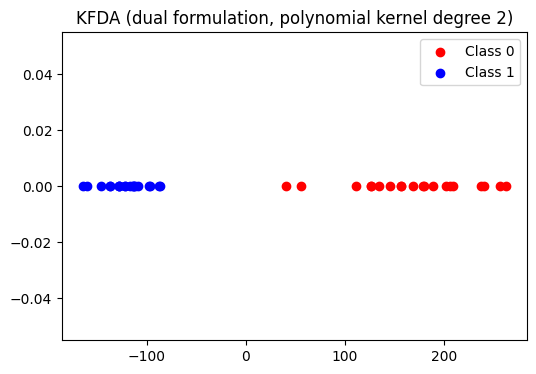

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#  Kernel Fisher Discriminant Analysis (Dual formulation)
#  Based on Mika et al., "Fisher Discriminant Analysis with Kernels", 1999
# ============================================================

def polynomial_kernel(X, Y=None, degree=2, c=1.0):
    """Inhomogeneous polynomial kernel: (x·y + c)^degree"""
    if Y is None:
        Y = X
    return (X @ Y.T + c) ** degree


class KFDA_Dual:
    def __init__(self, kernel=polynomial_kernel, n_components=1, **kernel_params):
        self.kernel = kernel
        self.kernel_params = kernel_params
        self.n_components = n_components

    def fit(self, X, y):
        """Fit the KFDA model using the dual formulation (Mika et al., 1999)."""
        self.X_fit_ = X
        y = np.asarray(y)
        classes = np.unique(y)
        if len(classes) != 2:
            raise ValueError("Current implementation supports only binary classification.")
        n = len(y)

        # Kernel (Gram) matrix
        K = self.kernel(X, X, **self.kernel_params)

        # Class indices
        I1 = np.where(y == classes[0])[0]
        I2 = np.where(y == classes[1])[0]
        n1, n2 = len(I1), len(I2)

        # Mean feature vectors in RKHS (Hilbert space)
        e1 = np.zeros((n, 1)); e1[I1] = 1.0 / n1
        e2 = np.zeros((n, 1)); e2[I2] = 1.0 / n2
        m1 = K @ e1
        m2 = K @ e2

        # --- Mika formulation ---
        # Between-class scatter in kernel space
        M = m1 - m2

        # Within-class scatter
        K1 = K[:, I1] - m1
        K2 = K[:, I2] - m2
        Sw = K1 @ K1.T / n1 + K2 @ K2.T / n2

        # Regularization to avoid singularity
        Sw += 1e-6 * np.eye(n)

        # Solve the generalized eigenvalue problem: (M M^T) α = λ S_w α
        A = np.linalg.pinv(Sw) @ (M @ M.T)
        eigvals, eigvecs = np.linalg.eigh(A)

        # Sort eigenvectors by descending eigenvalue
        idx = np.argsort(-eigvals)
        eigvecs = eigvecs[:, idx]
        eigvals = eigvals[idx]

        # Keep the top n_components discriminant directions
        self.alphas_ = eigvecs[:, :self.n_components]
        self.classes_ = classes
        self.m1_ = m1
        self.m2_ = m2
        self.K_ = K
        return self

    def project(self, X):
        """Project new samples into the discriminant subspace."""
        K_test = self.kernel(X, self.X_fit_, **self.kernel_params)
        return np.real(K_test @ self.alphas_)

    def predict(self, X):
        """Classify new samples using the sign of the projection."""
        Z = self.project(X)
        return np.where(Z > 0, self.classes_[0], self.classes_[1])


# ============================================================
#  Example usage
# ============================================================
if __name__ == "__main__":
    np.random.seed(0)

    # Synthetic 2D dataset: two Gaussian blobs
    X1 = np.random.randn(20, 2) + np.array([2, 2])
    X2 = np.random.randn(20, 2) + np.array([-2, -2])
    X = np.vstack((X1, X2))
    y = np.array([0]*20 + [1]*20)

    # Train KFDA with a polynomial kernel (degree 2)
    model = KFDA_Dual(kernel=polynomial_kernel, degree=2, c=1)
    model.fit(X, y)

    # Projection of data
    Z = model.project(X)

    # Visualization
    plt.figure(figsize=(6, 4))
    plt.scatter(Z[:20], np.zeros(20), color='red', label='Class 0')
    plt.scatter(Z[20:], np.zeros(20), color='blue', label='Class 1')
    plt.title("KFDA (dual formulation, polynomial kernel degree 2)")
    plt.legend()
    plt.show()


In [21]:
import csv
import sys 
import numpy as np
import matplotlib.pyplot as plt

def get_labels_from_csv(csvfile):
    """
    Récupère les étiquettes (classes) du fichier CSV
    Gère la conversion 'spam'/'ham' en 1/0
    """
    labels = []
    with open(csvfile, errors='ignore') as file:
        reader = csv.reader(file, delimiter=',')
        for row in reader:
            try: 
                # On nettoie la valeur et on gère le texte ou les entiers
                val = row[1].strip().lower()
                if val == 'spam':
                    labels.append(1)
                elif val == 'ham':
                    labels.append(0)
                else:
                    labels.append(int(val))
            except (ValueError, IndexError):
                continue
    return np.array(labels)

filename = "data/spam.csv"

# A : Récupération de la matrice document-terme et des étiquettes
print("Construction de la matrice document-terme...")
X = dtmat_from_csv(filename, purge=True)
y = get_labels_from_csv(filename)

# CORRECTION : Ajustement des dimensions (suppression de l'en-tête dans X)
if X.shape[0] > y.shape[0]:
    # On garde seulement le nombre de lignes correspondant aux étiquettes trouvées
    # Cela élimine l'en-tête ou les lignes malformées lues par dtmat
    X = X[(X.shape[0] - y.shape[0]):] 
    # Si l'ordre est inversé (en-tête au début), utiliser plutôt : X = X[1:] ou X[:y.shape[0]]
    # Ici on coupe l'excédent pour aligner.
    X = X[:y.shape[0]]

# Vérification des dimensions
if X.shape[0] != y.shape[0]:
    print(f"Erreur: le nombre de documents ({X.shape[0]}) et d'étiquettes ({y.shape[0]}) ne correspond pas.")
    sys.exit(1)

# B : Entraînement du modèle KFDA
print("Entraînement du modèle KFDA...")
kdfa = KFDA_Dual(kernel = polynomial_kernel, degree = 1, c = 1)
kdfa.fit(X, y)

# C : Projection des données
print("Projection des données...")
Z = kdfa.project(X)
y_pred = kdfa.predict(X)

# Calcul Accuracy
accuracy = np.mean(y_pred == y)
print(f"Accuracy sur les données d'entraînement: {accuracy*100:.2f}%")

plt.figure(figsize=(8, 5))

classes = np.unique(y)
z_class1 = Z[y == classes[0]]
z_class2 = Z[y == classes[1]]

# Affichage des histogrammes
plt.hist(z_class1, bins=30, alpha=0.6, label=f'Classe {classes[0]}', color='red', density=True)
plt.hist(z_class2, bins=30, alpha=0.6, label=f'Classe {classes[1]}', color='blue', density=True)

plt.title("Distribution des tweets après projection KFDA")
plt.xlabel("Valeur projetée (Axe discriminant)")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Construction de la matrice document-terme...
Entraînement du modèle KFDA...


ValueError: Current implementation supports only binary classification.

### Question 7

We will now slightely improve the above kernel by replacing the natural dot product 
$$<\boldsymbol{x},\boldsymbol{y}>$$ 
by 
$$ \sum_i \min(\boldsymbol{x}_i, \boldsymbol{y}_i) $$
resulting in

$$f(\boldsymbol{x},\boldsymbol{y})= (1+\sum_i \min(\boldsymbol{x}_i, \boldsymbol{y}_i) )^n$$

Is $f$ a positive semidefinite kernel ? Either prove that it is, or give a counter-example.

### Question 8

Irrespective of your answer to question 8, try to separate the two classes using KFDA_Dual, and $f$ as then kernel? 

Report your classification results, possibly varying $n$ (be reasonable with values, high $n$ may cause floating point exceptions, as in the last question). You should likely obtain decent (~ 75% accuracy, say) but not outstanding results.  This, however, is highly dependent on the dataset and classes you chose.

In [10]:
### Your answer here

### Question 9

One reason why the obtained accuracy is not fantastic is that the vector model we are using is blind to bigrams. For instance, we may encounter (normalized) words "donald", and "trump" separately in a document, but this is very different from "donald trump".

One way to fix this is to include bigrams in the vocabulary : for two consecutive words, like "donald trump", we would add a synthetic word "donald_trump" to the vocabulary. 

Add an extra "bigram" parameter to voc_from_csv() to do so, and compare your results to those of question 9. Bigrams can be generated very simply using a code similar to this one:

In [11]:
w=['I','think','traveling','to','Rio','next','winter','would','be','great']
[w[i]+'_'+w[i+1] for i in range(0,len(w)-1)]

['I_think',
 'think_traveling',
 'traveling_to',
 'to_Rio',
 'Rio_next',
 'next_winter',
 'winter_would',
 'would_be',
 'be_great']